In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

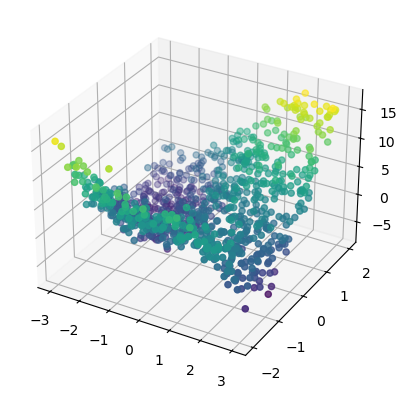

In [3]:
# generate data

rng = np.random.default_rng(1)
n = 1000

x1 = rng.uniform(-3, 3, size=n)
x2 = rng.uniform(-2, 2, size=n)
x3 = rng.normal(size=n)
x4 = rng.normal(size=n)

y = 3 * np.sin(x1) + 2 * x2**2 + 1.5 * x1 * x2 \
    + rng.normal(scale=1.5, size=n)

ax = plt.subplot(projection='3d') 
ax.scatter(x1, x2, y, c=y) 
plt.show()

X = pd.DataFrame({
    "x1": x1, "x2": x2, "x3": x3, "x4": x4
})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

In [4]:
# decision tree (baseline)

tree1 = DecisionTreeRegressor(max_depth=2, random_state=1)
tree2 = DecisionTreeRegressor(max_depth=5, random_state=1)
tree3 = DecisionTreeRegressor(max_depth=None, random_state=1)

tree1.fit(X_train, y_train)
tree2.fit(X_train, y_train)
tree3.fit(X_train, y_train)

"""
print("tree1 (max_depth=2)")
print("train_score =", tree1.score(X_train, y_train))
print("test_score  =", tree1.score(X_test, y_test))

print("\ntree2 (max_depth=5)")
print("train_score =", tree2.score(X_train, y_train))
print("test_score  =", tree2.score(X_test, y_test))

print("\ntree3 (max_depth=None)")
print("train_score =", tree3.score(X_train, y_train))
print("test_score  =", tree3.score(X_test, y_test))
"""

print("\ntree1 (max_depth=2)")
print("train_RMSE =", np.sqrt(mean_squared_error(y_train, tree1.predict(X_train))))
print("test_RMSE  =", np.sqrt(mean_squared_error(y_test, tree1.predict(X_test))))

print("\ntree2 (max_depth=5)")
print("train_RMSE =", np.sqrt(mean_squared_error(y_train, tree2.predict(X_train))))
print("test_RMSE  =", np.sqrt(mean_squared_error(y_test, tree2.predict(X_test))))

print("\ntree3 (max_depth=None)")
print("train_RMSE =", np.sqrt(mean_squared_error(y_train, tree3.predict(X_train))))
print("test_RMSE  =", np.sqrt(mean_squared_error(y_test, tree3.predict(X_test))))


tree1 (max_depth=2)
train_RMSE = 2.779108500972541
test_RMSE  = 2.7339149510509477

tree2 (max_depth=5)
train_RMSE = 1.5732425142091846
test_RMSE  = 1.8498162346200189

tree3 (max_depth=None)
train_RMSE = 0.0
test_RMSE  = 2.1711829308544206


In [5]:
# random forest

rf = RandomForestRegressor(
    n_estimators=200,
    max_features=0.75,  # may use "sqrt" when many features
    random_state=1,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("feature_importance:", rf.feature_importances_)
print("train_RMSE =", np.sqrt(mean_squared_error(y_train, rf.predict(X_train))))
print("test_RMSE  =", np.sqrt(mean_squared_error(y_test, rf.predict(X_test))))

feature_importance: [0.38302926 0.55450391 0.02932161 0.03314522]
train_RMSE = 0.6417360671423842
test_RMSE  = 1.5845252575139441


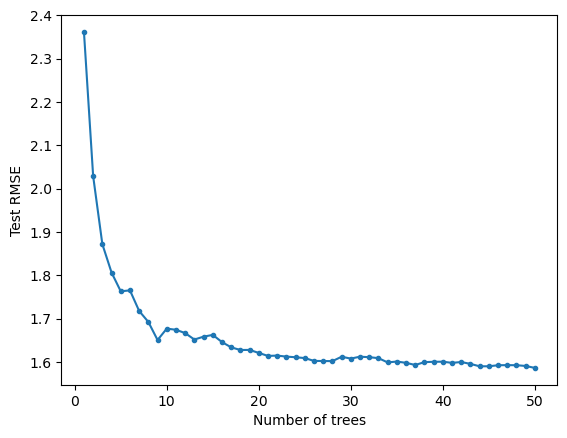

In [6]:
rf_mse = []

for n_trees in range(1, 51):
    rf = RandomForestRegressor(
        n_estimators=n_trees,
        max_features=0.75,     # bagging when =1.0
        random_state=1,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    rf_mse.append(np.sqrt(mean_squared_error(y_test, pred)))

plt.plot(range(1,51), rf_mse, marker=".")
plt.xlabel("Number of trees")
plt.ylabel("Test RMSE")
plt.show()

In [33]:
# gradient boosting

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.02,
    max_depth=4,
    random_state=1
)
gb.fit(X_train, y_train)

print("feature_importance:", rf.feature_importances_)
print("train_RMSE =", np.sqrt(mean_squared_error(y_train, gb.predict(X_train))))
print("test_RMSE  =", np.sqrt(mean_squared_error(y_test, gb.predict(X_test))))

feature_importance: [0.38782581 0.54722805 0.02857732 0.03636882]
train_RMSE = 1.2345869646324794
test_RMSE  = 1.6167168787982173


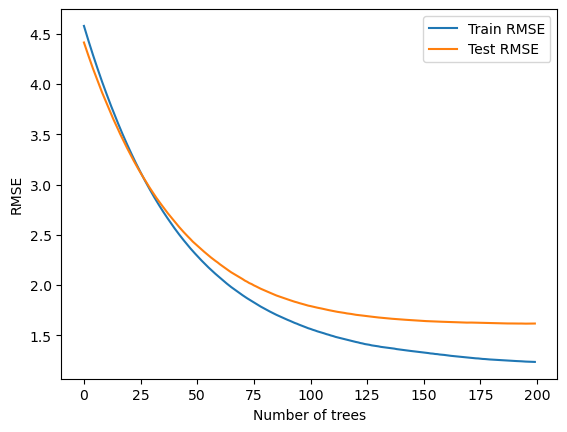

In [34]:
train_rmse = []
test_rmse = []

for train_pred, test_pred in zip(
    gb.staged_predict(X_train),
    gb.staged_predict(X_test)
):
    train_rmse.append(np.sqrt(mean_squared_error(y_train, train_pred)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, test_pred)))

plt.plot(train_rmse, label="Train RMSE")
plt.plot(test_rmse, label="Test RMSE")
plt.xlabel("Number of trees")
plt.ylabel("RMSE")
plt.legend()
plt.show()